# Stage 06: the score function

**A dimensionless geometric penalty, computed from the arrangement itself
and the plan geometry — no loads, no sections, no prices, no units.**

This stage used to be a cost function: it sized every beam and column from a
catalogue, priced the steel per kilogram, charged for off-grid columns and
extra section sizes in pounds, and billed erection by the crew-hour. All of
that is gone, deliberately. A cost model is only as defensible as its unit
rates, and the honest answer to "where did your rates come from?" was
"indicative figures". The five terms below keep the *structural reasoning*
of the old function — quantity, bending demand, regularity, architectural
intrusion, repetition — and drop only the money. The root README's changelog
records exactly what was deleted and where each piece of reasoning went.

## The five terms

Every term is dimensionless once normalised across the candidate set, and
every term is monotone — higher is worse — so the weights are the only free
parameters.

| term | what it measures | replaces |
|---|---|---|
| `t_density` | columns per unit footprint | material + foundation count, unpriced |
| `t_span_demand` | span² × tributary width, summed and normalised | the deleted beam sizing |
| `t_irregularity` | cov of bay sizes, x plus y | (new axis, standard in the literature) |
| `t_off_wall` | fraction of columns outside walls | the off-grid penalty, unpriced |
| `t_repetition` | distinct bay sizes over bays | the distinct-section-count penalty |

`t_span_demand` deserves the explicit defence: the peak sagging moment of a
uniformly loaded beam is `w·L²/8` per tributary metre. Dropping the constant
`w/8` leaves a quantity *proportional to bending demand* that needs no load
value and no section catalogue. The physics is preserved up to a constant;
only the unfounded unit rates are gone. Spans are measured between actual
columns on each grid line, so a sparse line with a long unsupported run is
charged for it.

## Normalisation: median and IQR, not min–max

Each term is reduced to a robust z-score within the candidate set of one
plan: `(t − median) / IQR`, with a scaled-MAD fallback when the IQR
degenerates. Min–max was rejected because a single outlier candidate
rescales every other score and ties the scalar to the size of the
enumeration (loophole L5); the median and IQR are unmoved by anything
outside the central half of the candidates.

## Two weight vectors

* **Algorithmic** (`SCORE_MODE="algo"`): all ones. Equal weighting is the
  deliberate maximum-entropy choice, defended not by argument but by the
  stage 12 sensitivity analysis: ±50% on any single weight, and
  leave-one-term-out, with the ranking stability reported as Kendall's tau.
* **Learned** (`SCORE_MODE="learned"`): fitted in stage 08 by pairwise
  ranking — the derived ground truth against enumerated alternatives over
  the same plan's grid — the only non-circular way to learn them. The model
  is linear on term differences, so the learned vector reads directly
  against the algorithmic one below.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "09_full_pipeline"))
import pipeline as P

import inspect
print(inspect.getsource(P.score_terms))

def score_terms(arr, grid):
    """The five raw score terms of one arrangement. All are dimensionless
    once normalised across the candidate set, and all are monotone: higher
    is worse. The docstring of each term is the design rationale.

    t_density       column count over footprint area. A proxy for total
                    vertical-member quantity and foundation count, with no
                    price attached to either.
    t_span_demand   sum over beam runs of span^2 x tributary width, over
                    fx*fy*(fx+fy). Peak sagging moment in a uniformly loaded
                    beam is w L^2/8 per tributary metre, so dropping the
                    common factor w/8 leaves a quantity proportional to
                    bending demand that needs no load value and no section.
                    This is the honest replacement for the deleted beam
                    sizing: the physics survives up to a constant, only the
                    unfounded unit rates are

In [2]:
# Score the sample office plan's 33 candidates.
walls = json.loads((Path("..") / "data" / "sample_plan.json").read_text())["walls"]
cons = json.loads((Path("..") / "data" / "constraints.json").read_text())
grid = P.parse_plan(walls, cons)
arrs = P.generate(grid)
table = P.score_arrangements(arrs, grid, mode="algo")
table["n_columns"] = [len(a["columns"]) for a in arrs]
print(f"{len(arrs)} candidates")
best = table.penalty.idxmin()
print(f"winner: #{best} with {table.n_columns[best]} columns, "
      f"penalty {table.penalty[best]:.2f}")
table.sort_values("penalty").head(8)[
    ["n_columns"] + P.SCORE_TERMS + ["penalty"]].round(3)

33 candidates
winner: #28 with 20 columns, penalty -3.53


,n_columns,t_density,t_span_demand,t_irregularity,t_off_wall,t_repetition,penalty
28,20,0.023,0.300,0.000,0.0,0.286,-3.534
0,34,0.039,0.217,0.000,0.0,0.200,-2.970
32,12,0.014,0.400,0.000,0.0,0.400,-1.952
23,25,0.029,0.267,0.333,0.0,0.375,-1.886
13,25,0.029,0.267,0.333,0.0,0.375,-1.886
5,30,0.035,0.233,0.333,0.0,0.333,-1.848
1,28,0.032,0.250,0.354,0.0,0.333,-1.791
20,24,0.028,0.283,0.333,0.0,0.375,-1.636


## How independent are the five terms?

If two terms always agree, one of them is decoration. The correlations below
are measured across the candidate set of a held-out dwelling (a denser,
more realistic search space than the office plan's 33).

In [3]:
plan = json.loads((Path("..") / "data" / "demo_plans" / "demo_02.json").read_text())
dcons = {"n_stories": plan["n_stories"], "min_span": 0.5, "max_span": 8.0,
         "merge_tol": "auto", "min_wall_frac": 0.05,
         "fixed_columns": plan.get("annotated_columns", []),
         "offer_skew_columns": False, "column_free_zones": []}
dgrid = P.parse_plan(plan["walls"], dcons)
dcands = P.generate(dgrid)
dtable = P.score_arrangements(dcands, dgrid, mode="algo")
corr = dtable[P.SCORE_TERMS].corr()
print(f"{len(dcands)} candidates on demo_02")
corr.round(2)

3997 candidates on demo_02


,t_density,t_span_demand,t_irregularity,t_off_wall,t_repetition
t_density,1.00,-0.75,0.41,0.37,-0.19
t_span_demand,-0.75,1.00,0.12,-0.36,0.16
t_irregularity,0.41,0.12,1.00,0.09,0.04
t_off_wall,0.37,-0.36,0.09,1.00,-0.03
t_repetition,-0.19,0.16,0.04,-0.03,1.00


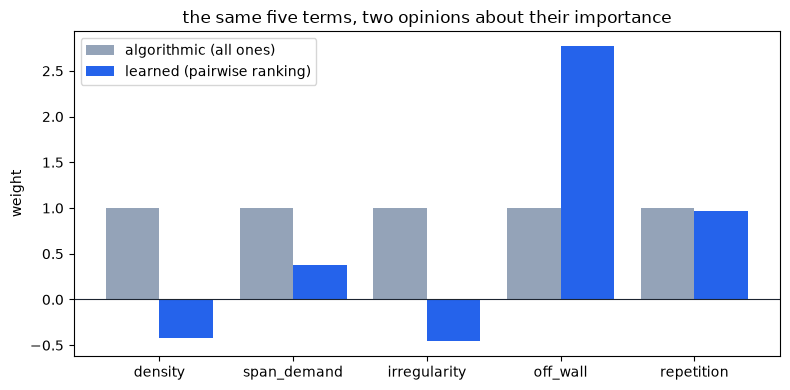

pairwise accuracy on held-out plans: learned 0.894 ± 0.006, algorithmic vector 0.747


In [4]:
# The two weight vectors, side by side.
learned = json.loads((Path("..") / "data" / "learned_weights.json").read_text())
w_algo = P.ALGO_WEIGHTS
w_learn = learned["weights"]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(P.SCORE_TERMS))
ax.bar(x - 0.2, [w_algo[t] for t in P.SCORE_TERMS], 0.4,
       label="algorithmic (all ones)", color="#94a3b8")
ax.bar(x + 0.2, [w_learn[t] for t in P.SCORE_TERMS], 0.4,
       label="learned (pairwise ranking)", color="#2563eb")
ax.axhline(0, color="#1c2430", lw=0.8)
ax.set_xticks(x, [t.replace("t_", "") for t in P.SCORE_TERMS])
ax.set_ylabel("weight")
ax.legend()
ax.set_title("the same five terms, two opinions about their importance")
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "06_weights.png", dpi=150,
            bbox_inches="tight")
plt.show()
print(f"pairwise accuracy on held-out plans: learned "
      f"{learned['pairwise_accuracy_test_mean']:.3f} "
      f"± {learned['pairwise_accuracy_test_std']:.3f}, "
      f"algorithmic vector {learned['algorithmic_vector_accuracy_same_fold']:.3f}")

## What the learned weights say, and the two caveats they come with

The learned vector *agrees* with the design intuition on span demand and
repetition, puts most of its confidence in `t_off_wall`, and turns
`t_density` and `t_irregularity` **negative**: across 50k+ ranking pairs,
the real derived arrangement is *denser* and *less regular* than the
enumerated alternatives to its own grid. That is not a bug; it is what an
equivalent-frame idealisation of a wall-bearing building looks like — the
columns stand where the walls are, and Swiss party walls are not on a neat
module. It also predicts, correctly, that the algorithmic vector will rank
the ground truth poorly (stage 12 measures exactly this).

Caveat one: `t_off_wall` is zero for every ground truth **by construction**
(derived columns sit inside walls by definition), so its large learned
weight partly restates the derivation rather than discovering practice.
Caveat two: the learned mode shares one signal family with nothing — it is
trained on enumerated line-subset alternatives, never on the judges'
transplant/perturbation negatives and never on the algorithmic score's
output, which would have been a tautology (loophole L6). The one overlap
that remains — both the ranker's negatives and the judges' negatives contain
lattice-like arrangements — is stated in the limitations rather than hidden.

## Where the defence of the weights actually lives

Stage 12 perturbs every weight by ±50%, drops each term in turn, and reports
Kendall's tau against the nominal ranking plus the change in top-1/top-5.
A weight vector nobody can justify *is* acceptable if the ranking barely
moves when you shake it — that is the defensible position, and the numbers
live in `data/evaluation_weights_sensitivity.csv`.